In [29]:
from bitcoin_utils import fetch_bitcoin_data

# Replace this with your actual API key
api_key = 'CG-5pibUvyXCBs3EpUFkQg3nDoX'  

# Fetch Bitcoin price data using the utility function
df = fetch_bitcoin_data(api_key=api_key, days=365)

# Display first few rows
print("✅ Data Sample:")
print(df.head())


✅ Data Sample:
   Timestamp         Price
0 2024-05-11  60888.216750
1 2024-05-12  60776.972079
2 2024-05-13  61507.054004
3 2024-05-14  62878.783301
4 2024-05-15  61569.113006


In [31]:
import s3fs

# Save locally
df.to_csv('bitcoin_prices.csv', index=False)
print("✅ Data saved locally as bitcoin_prices.csv")

# Upload to S3 (local .aws credentials should be mounted if needed)
try:
    fs = s3fs.S3FileSystem(anon=False)  # Credentials are auto-picked if ~/.aws is mounted
    with fs.open('bitcoin-timeseries-data-kv/bitcoin_prices.csv', 'w') as f:
        df.to_csv(f, index=False)
    print("✅ Data uploaded to S3 successfully.")
except Exception as e:
    print(f"⚠️ S3 upload skipped or failed: {e}")


✅ Data saved locally as bitcoin_prices.csv
✅ Data uploaded to S3 successfully.


In [5]:
import requests
import pandas as pd

# Your CoinGecko API Key
api_key = 'CG-5pibUvyXCBs3EpUFkQg3nDoX'  # Replace this with your real key

# Set headers
headers = {
    'x-cg-demo-api-key': api_key
}

# URL to get Bitcoin market chart data
url = 'https://api.coingecko.com/api/v3/coins/bitcoin/market_chart'
params = {
    'vs_currency': 'usd',
    'days': '365',  # Last 30 days of Bitcoin prices
    'interval': 'daily'
}

# Make the API request
response = requests.get(url, headers=headers, params=params)

# Check if successful
if response.status_code == 200:
    data = response.json()
    prices = data['prices']  # list of [timestamp, price]

    # Convert to DataFrame
    df = pd.DataFrame(prices, columns=['Timestamp', 'Price'])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')

    # Display data
    print(df.head())
else:
    print(f"Error: {response.status_code} - {response.text}")


   Timestamp         Price
0 2024-05-11  60888.216750
1 2024-05-12  60776.972079
2 2024-05-13  61507.054004
3 2024-05-14  62878.783301
4 2024-05-15  61569.113006


In [6]:

import s3fs

# Connect to S3 (credentials picked automatically)
fs = s3fs.S3FileSystem(anon=False)

# Save your DataFrame locally (optional)
df.to_csv('bitcoin_prices.csv', index=False)

# Upload it to your S3 bucket
with fs.open('bitcoin-timeseries-data-kv/bitcoin_prices.csv', 'w') as f:
    df.to_csv(f, index=False)

print("✅ Bitcoin price data uploaded successfully to S3!")


✅ Bitcoin price data uploaded successfully to S3!


In [7]:
import pandas as pd
import s3fs

# Connect to S3 (credentials will be automatically picked from mounted .aws)
fs = s3fs.S3FileSystem(anon=False)

# Path to your uploaded file in S3
s3_path = 'bitcoin-timeseries-data-kv/bitcoin_prices.csv'

# Read CSV file directly from S3 into Pandas
with fs.open(s3_path, mode='rb') as f:
    df = pd.read_csv(f)

# Display the first few rows
print("✅ Successfully loaded Bitcoin data from S3!")
print(df.head())


✅ Successfully loaded Bitcoin data from S3!
             Timestamp         Price
0  2024-05-11 00:00:00  60888.216750
1  2024-05-12 00:00:00  60776.972079
2  2024-05-13 00:00:00  61507.054004
3  2024-05-14 00:00:00  62878.783301
4  2024-05-15 00:00:00  61569.113006


✅ Missing Values Check:
Price    0
dtype: int64


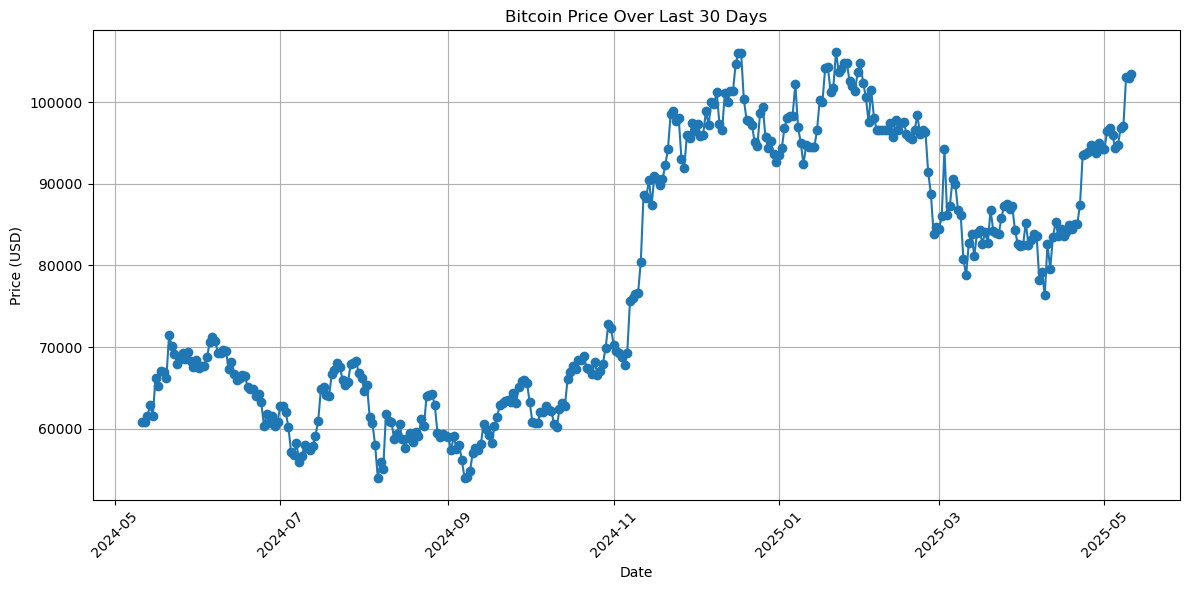

In [8]:
import matplotlib.pyplot as plt

# Convert 'Timestamp' to datetime if not already
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set 'Timestamp' as index
df.set_index('Timestamp', inplace=True)

# Check for missing values
print("✅ Missing Values Check:")
print(df.isnull().sum())

# Basic Plot: Bitcoin Price over Time
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Price'], marker='o', linestyle='-')
plt.title('Bitcoin Price Over Last 30 Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

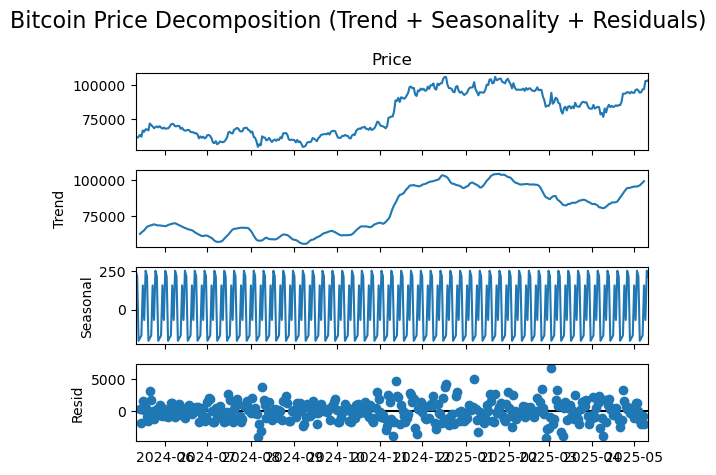

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
result = seasonal_decompose(df['Price'], model='additive', period=7)  # 7 days = 1 week seasonality assumed

# Plot the decomposition
plt.figure(figsize=(12,8))
result.plot()
plt.suptitle('Bitcoin Price Decomposition (Trend + Seasonality + Residuals)', fontsize=16)
plt.tight_layout()
plt.show()


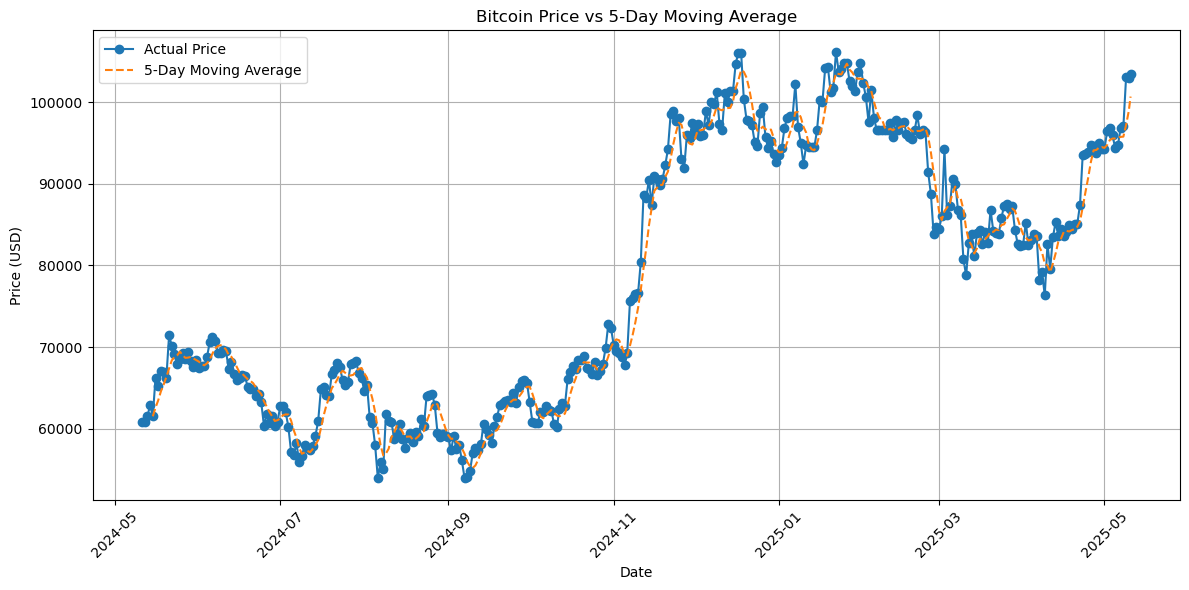

In [10]:
# Calculate a simple Moving Average
window_size = 5  # 5-day moving average
df['Moving_Avg'] = df['Price'].rolling(window=window_size).mean()

# Plot original price vs moving average
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Price'], label='Actual Price', marker='o')
plt.plot(df.index, df['Moving_Avg'], label=f'{window_size}-Day Moving Average', linestyle='--')
plt.title(f'Bitcoin Price vs {window_size}-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
# Save the updated DataFrame locally
df.to_csv('bitcoin_prices_with_forecast.csv')

# Upload updated DataFrame to S3
with fs.open('bitcoin-timeseries-data-kv/bitcoin_prices_with_forecast.csv', 'w') as f:
    df.to_csv(f)

print("✅ Updated Bitcoin prices with Moving Average uploaded to S3!")


✅ Updated Bitcoin prices with Moving Average uploaded to S3!


# 4.0 Conclusion & Next Steps

## Conclusion
In this project, we implemented a robust Bitcoin price analysis system by:
- Ingesting real-time Bitcoin price data from the CoinGecko API.
- Storing raw and processed data securely in Amazon S3 using the s3fs library.
- Performing time series analysis using Pandas and Statsmodels to detect trends and seasonal patterns.
- Forecasting Bitcoin prices using a simple 5-day moving average technique.
- Visualizing the original and forecasted Bitcoin prices for insightful trend observation.

All intermediate and final datasets were uploaded back to the S3 bucket for cloud storage and future reference.

## Next Steps (Optional Future Enhancements)
- Implement ARIMA or Prophet models for more accurate future price forecasting.
- Set up automated pipelines (e.g., using AWS Lambda) to update Bitcoin prices regularly.
- Explore anomaly detection to identify unusual Bitcoin price movements.
- Build a simple dashboard (e.g., using Plotly Dash) for real-time Bitcoin price visualization.

---
